# Module 3 — AR, MA, ARIMA and Random walk(Following Module 2 Pipeline)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pmdarima as pm
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import scipy.stats as stats  # Added for detailed Normality validation
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Global plotting dimensions and theme configuration matching Module 2
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
path = "../data/airline-passengers.csv"
df = pd.read_csv(path)

# Convert to datetime, map uniform monthly frequency, and bind to index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (144, 1)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 3. Train-Test Split

In [3]:
train = df.iloc[:-24]
test = df.iloc[-24:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (120, 1)
Test Shape: (24, 1)


## 3. Stationarity Testing (ADF Test)
We must establish stationarity before isolating our AR and MA patterns.

In [4]:
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] <= 0.05:
        print("Conclusion: Stationary (Reject Null Hypothesis)")
    else:
        print("Conclusion: Non-Stationary (Fail to Reject Null Hypothesis)")

print("--- Original Passengers Series ---")
adf_test(df['Passengers'])



--- Original Passengers Series ---
ADF Statistic: 0.8153688792060352
p-value: 0.9918802434376408
Conclusion: Non-Stationary (Fail to Reject Null Hypothesis)


## RANDOM WALK DIAGNOSTICS 

=== Random Walk Diagnostics on Original Series ===


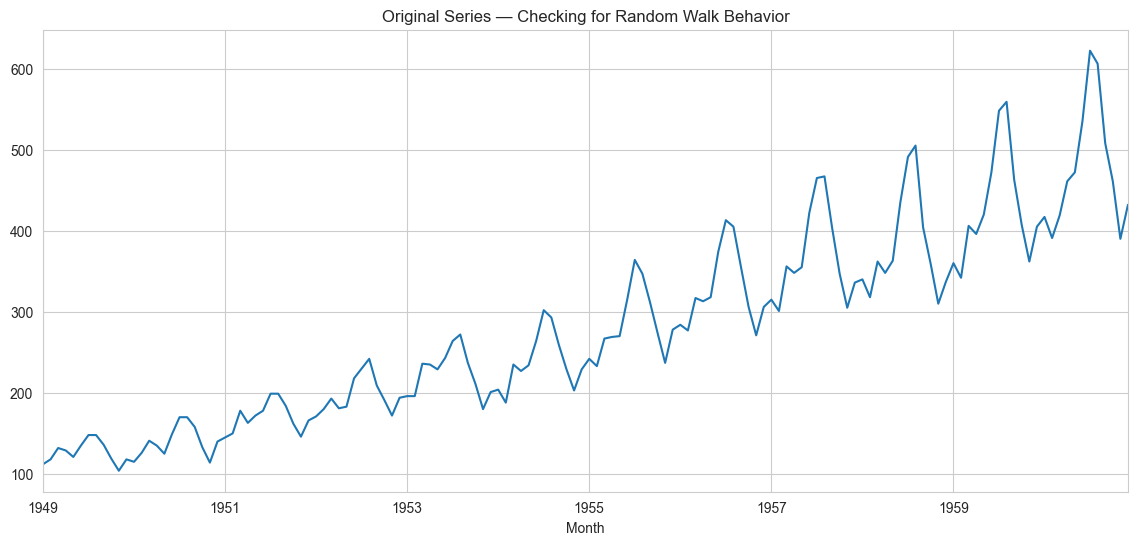

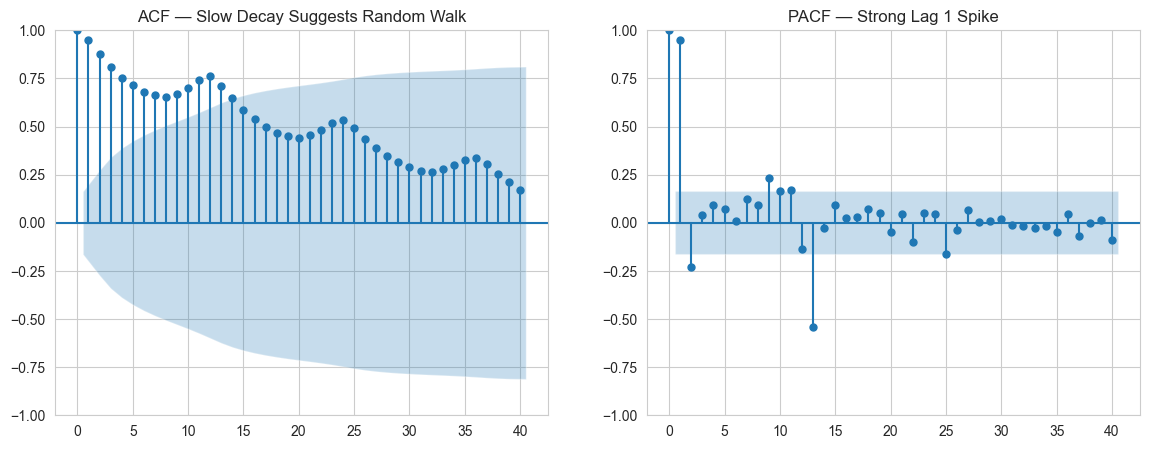

ADF Statistic: 0.8153688792060352
p-value: 0.9918802434376408
Conclusion: Non-Stationary — Random Walk behavior likely


In [ ]:

print("=== Random Walk Diagnostics on Original Series ===")

# 1. Visual inspection
df['Passengers'].plot(title="Original Series — Checking for Random Walk Behavior")
plt.show()

# 2. ACF / PACF on the original series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title("ACF — Slow Decay Suggests Random Walk")

plot_pacf(df['Passengers'], lags=40, ax=axes[1])
axes[1].set_title("PACF — Strong Lag 1 Spike")

plt.show()

# 3. ADF Test on original series
result = adfuller(df['Passengers'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] > 0.05:
    print("Conclusion: Non-Stationary — Random Walk behavior likely")
else:
    print("Conclusion: Stationary")


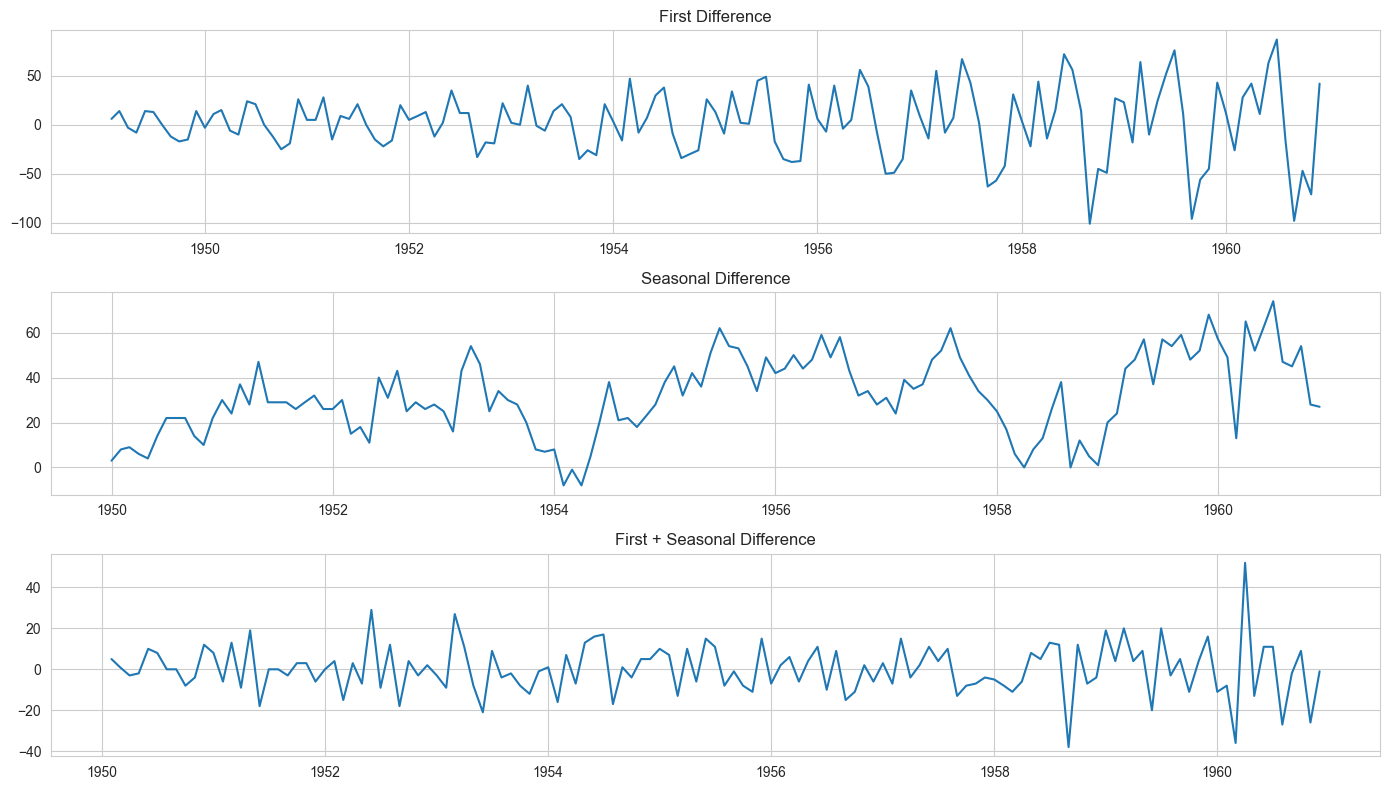


--- ADF Test: First Difference Only ---
ADF Statistic: -2.8292668241699945
p-value: 0.05421329028382621
Conclusion: Non-Stationary (Fail to Reject Null Hypothesis)

--- ADF Test: Seasonal Difference Only (lag 12) ---
ADF Statistic: -3.3830207264924796
p-value: 0.011551493085515008
Conclusion: Stationary (Reject Null Hypothesis)

--- ADF Test: First + Seasonal Difference (d=1, D=1) ---
ADF Statistic: -15.595618083746334
p-value: 1.8565116001234705e-28
Conclusion: Stationary (Reject Null Hypothesis)


In [6]:
# --- Differencing ---
df['Passengers_Diff'] = df['Passengers'].diff()
df['Passengers_Seasonal_Diff'] = df['Passengers'].diff(12)
df['Passengers_Diff_Seasonal'] = df['Passengers'].diff().diff(12)

fig, axes = plt.subplots(
    3,1,
    figsize=(14,8)
)

axes[0].plot(df['Passengers_Diff'])
axes[0].set_title("First Difference")

axes[1].plot(df['Passengers_Seasonal_Diff'])
axes[1].set_title("Seasonal Difference")

axes[2].plot(df['Passengers_Diff_Seasonal'])
axes[2].set_title("First + Seasonal Difference")

plt.tight_layout()
plt.show()

print("\n--- ADF Test: First Difference Only ---")
adf_test(df['Passengers_Diff'])

print("\n--- ADF Test: Seasonal Difference Only (lag 12) ---")
adf_test(df['Passengers_Seasonal_Diff'])

print("\n--- ADF Test: First + Seasonal Difference (d=1, D=1) ---")
adf_test(df['Passengers_Diff_Seasonal'])


## 4. Interactive Diagnostic Plots (ACF / PACF)

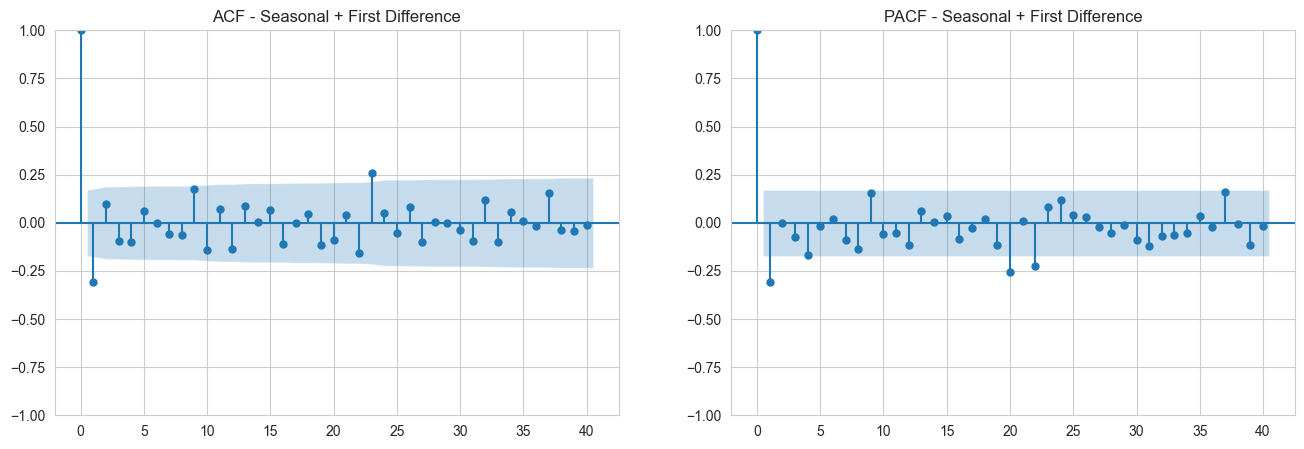

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['Passengers_Diff_Seasonal'].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF - Seasonal + First Difference")

plot_pacf(df['Passengers_Diff_Seasonal'].dropna(), lags=40, ax=axes[1])
axes[1].set_title("PACF - Seasonal + First Difference")

plt.show()


## 5. Pure Auto-Regressive (AR) Modeling
An explicit Auto-Regressive model depends only on its past lags. We define this by setting the Moving Average order ($q$) to $0$. For instance, an AR(1) process on the differenced series maps to order=(1, 1, 0):

In [8]:
print("--- Fitting Manual AR(1) Model ---")
ar_model = ARIMA(train['Passengers'], order=(1,1,0))
ar_results = ar_model.fit()
print(ar_results.summary())

--- Fitting Manual AR(1) Model ---
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -563.328
Date:                Sat, 13 Jun 2026   AIC                           1130.656
Time:                        18:26:28   BIC                           1136.215
Sample:                    01-01-1949   HQIC                          1132.913
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2858      0.093      3.074      0.002       0.104       0.468
sigma2       756.7940     80.855      9.360      0.000     598.321     915.267
Ljung-Box (L1) (Q

## 6. Pure Moving Average (MA) Modeling
A pure Moving Average process depends entirely on past forecast errors. We define this by explicitly setting the Auto-Regressive order ($p$) to $0$. For instance, an MA(1) process maps to order=(0, 1, 1):

In [9]:
print("--- Fitting Manual MA(1) Model ---")
ma_model = ARIMA(train['Passengers'], order=(0,1,1))
ma_results = ma_model.fit()
print(ma_results.summary())

--- Fitting Manual MA(1) Model ---
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -561.510
Date:                Sat, 13 Jun 2026   AIC                           1127.020
Time:                        18:26:29   BIC                           1132.578
Sample:                    01-01-1949   HQIC                          1129.277
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3824      0.094      4.076      0.000       0.199       0.566
sigma2       733.5500     81.729      8.975      0.000     573.364     893.736
Ljung-Box (L1) (Q

## 7. Integrated manual ARIMA Modeling

In [10]:
print("--- Fitting Combined ARIMA(1, 1, 1) Model ---")
manual_arima = ARIMA(train['Passengers'], order=(1,1,1))
manual_arima_results = manual_arima.fit()
print(manual_arima_results.summary())

--- Fitting Combined ARIMA(1, 1, 1) Model ---
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -559.714
Date:                Sat, 13 Jun 2026   AIC                           1125.429
Time:                        18:26:29   BIC                           1133.766
Sample:                    01-01-1949   HQIC                          1128.814
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5120      0.148     -3.469      0.001      -0.801      -0.223
ma.L1          0.8746      0.097      8.977      0.000       0.684       1.066
sigma2

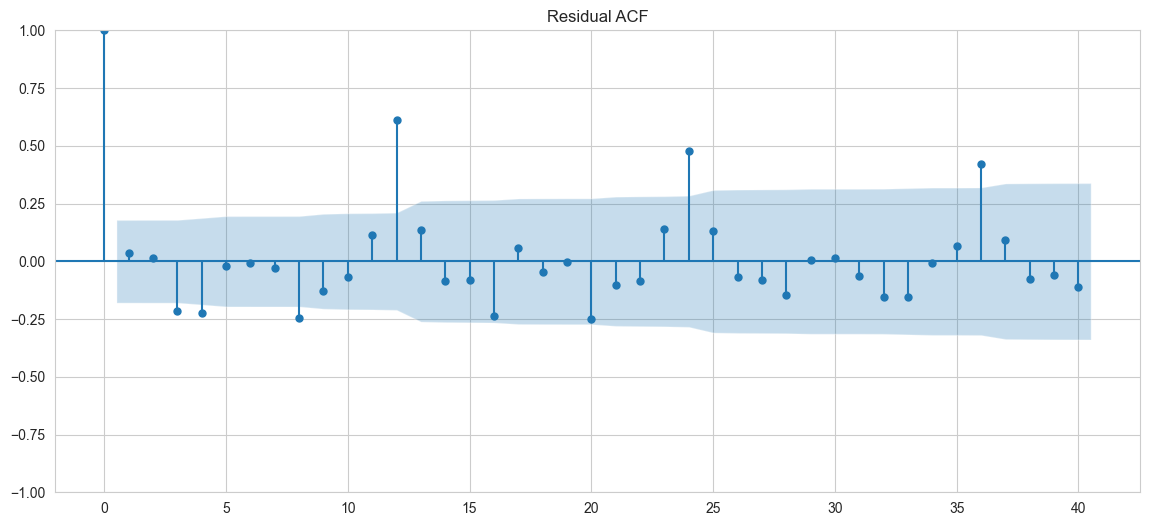

In [11]:
## Residual Diagnostics
residuals = manual_arima_results.resid

plot_acf(
    residuals,
    lags=40
)

plt.title("Residual ACF")
plt.show()

## Ljung–Box Test

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

print(lb)

      lb_stat     lb_pvalue
12  75.331436  3.180453e-11


## 7. Compare Models by AIC

In [13]:
comparison = pd.DataFrame({
    "Model": ["AR(1)", "MA(1)", "ARIMA(1,1,1)"],
    "AIC": [
        ar_results.aic,
        ma_results.aic,
        manual_arima_results.aic
    ]
})

print(comparison.sort_values("AIC"))

          Model          AIC
2  ARIMA(1,1,1)  1125.428593
1         MA(1)  1127.019850
0         AR(1)  1130.656324


## 8. Forecasting Future Values

In [14]:
forecast_obj = manual_arima_results.get_forecast(
    steps=len(test)
)

forecast_mean = forecast_obj.predicted_mean

forecast_ci = forecast_obj.conf_int()



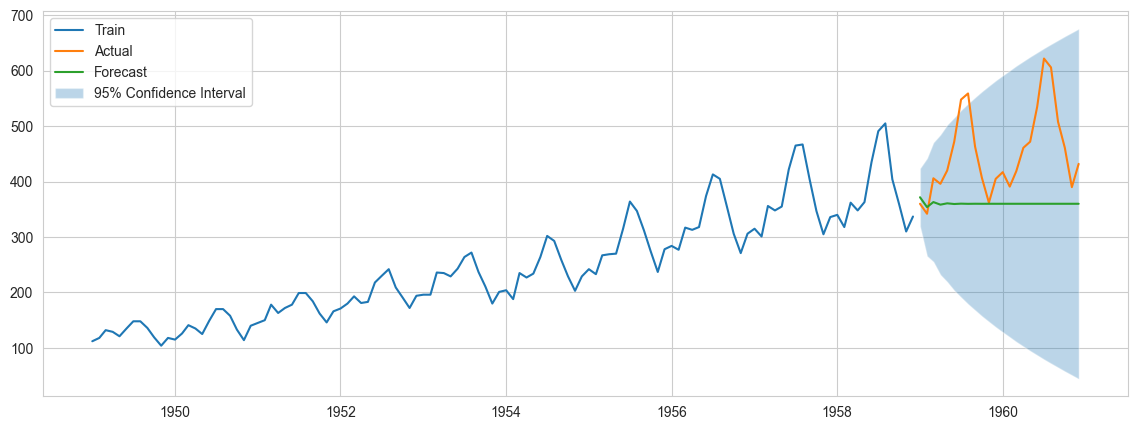

In [15]:
plt.figure(figsize=(14,5))

plt.plot(
    train.index,
    train['Passengers'],
    label='Train'
)

plt.plot(
    test.index,
    test['Passengers'],
    label='Actual'
)

plt.plot(
    test.index,
    forecast_mean,
    label='Forecast'
)

plt.fill_between(
    test.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.legend()
plt.show()

## Forecast Accuracy Metrics

In [16]:
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    
    return mae, rmse

evaluate_forecast(test['Passengers'], forecast_mean)

MAE : 93.9
RMSE: 118.64


(93.90498941579897, 118.64452730472216)

| Metric | Meaning                |
| ------ | ---------------------- |
| MAE    | Average Error          |
| RMSE   | Penalizes large errors |


## 8. Stepwise Optimization with Auto-ARIMA

### 1  Auto-ARIMA hyperparameter grid search without seasonal

In [17]:
# Auto-ARIMA hyperparameter grid search without seasonal
auto_model = pm.auto_arima(
    df['Passengers'],
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    d=1,
    seasonal=False
)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(3, 1, 2)   Log Likelihood                -682.543
Date:                Sat, 13 Jun 2026   AIC                           1377.086
Time:                        18:26:34   BIC                           1394.863
Sample:                    01-01-1949   HQIC                          1384.310
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2580      0.135      1.914      0.056      -0.006       0.522
ar.L2          0.3732      0.136      2.736      0.006       0.106       0.641
ar.L3         -0.3367      0.125     -2.684      0.0

#### Extract residuals from the best auto-ARIMA selection

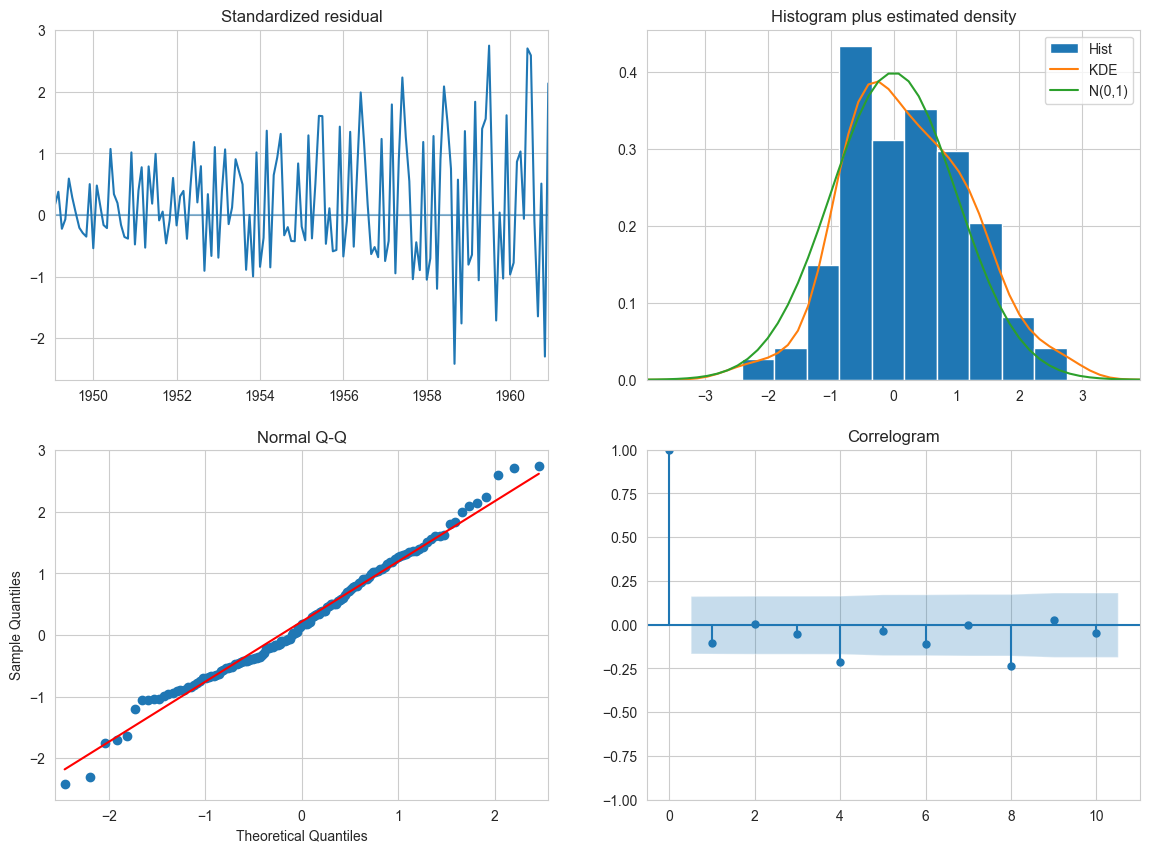

--- Statistical Normality Test Metrics ---
Jarque-Bera Statistic: 6.5359
Jarque-Bera p-value: 0.0381
Shapiro-Wilk Statistic: 0.9830
Shapiro-Wilk p-value: 0.0716

Conclusion: Residuals are Normally Distributed (Fail to reject H0)


In [18]:

residuals = auto_model.resid()

# A. Visual Diagnostic plots matching standard statsmodels evaluation metrics
auto_model.plot_diagnostics(figsize=(14, 10))
plt.show()

print("--- Statistical Normality Test Metrics ---")
# B. Jarque-Bera Test (Validating asymmetry and tails)
jb_stat, jb_p, skew, kurtosis = sm.stats.stattools.jarque_bera(residuals)
print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"Jarque-Bera p-value: {jb_p:.4f}")

# C. Shapiro-Wilk Normality Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

# D. Decision Breakdown
if shapiro_p > 0.05:
    print("\nConclusion: Residuals are Normally Distributed (Fail to reject H0)")
else:
    print("\nConclusion: Residuals are Not Perfectly Normal (Reject H0) — consider adding seasonality components (m=12).")

#### 2.  Auto-ARIMA hyperparameter grid search with seasonal
Although SARIMA is not part of this chapter, we briefly show the seasonal model so you can see how much better it performs on seasonal data.

In [19]:

auto_model_seasonal = pm.auto_arima(
    df['Passengers'],
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    d=1,
    seasonal=True,
    m=12,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)


print(auto_model_seasonal.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.47 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.36 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.23 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.51 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.50 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.10 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.68 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.60 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.41 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.11 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=2.07 sec
 ARIMA(0,1,1)(1,1,1)[12]     

# Extract residuals from the best auto-ARIMA selection-seasonal

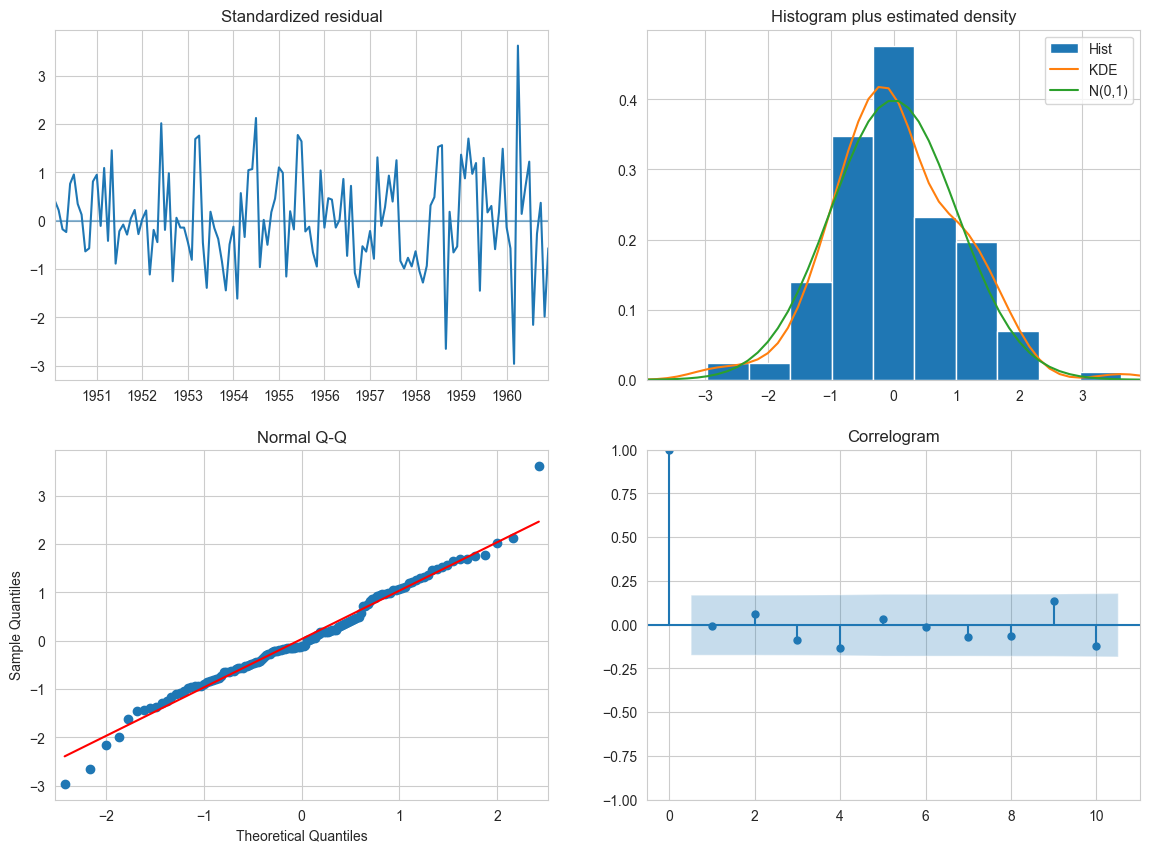

--- Statistical Normality Test Metrics ---
Jarque-Bera Statistic: 2056.4870
Jarque-Bera p-value: 0.0000
Shapiro-Wilk Statistic: 0.8141
Shapiro-Wilk p-value: 0.0000

Conclusion: Residuals are Not Perfectly Normal (Reject H0) — consider adding seasonality components (m=12).


In [20]:

residuals = auto_model_seasonal.resid()

# A. Visual Diagnostic plots matching standard statsmodels evaluation metrics
auto_model_seasonal.plot_diagnostics(figsize=(14, 10))
plt.show()

print("--- Statistical Normality Test Metrics ---")
# B. Jarque-Bera Test (Validating asymmetry and tails)
jb_stat, jb_p, skew, kurtosis = sm.stats.stattools.jarque_bera(residuals)
print(f"Jarque-Bera Statistic: {jb_stat:.4f}")
print(f"Jarque-Bera p-value: {jb_p:.4f}")

# C. Shapiro-Wilk Normality Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

# D. Decision Breakdown
if shapiro_p > 0.05:
    print("\nConclusion: Residuals are Normally Distributed (Fail to reject H0)")
else:
    print("\nConclusion: Residuals are Not Perfectly Normal (Reject H0) — consider adding seasonality components (m=12).")

## Conclusion:

Stationarity is essential → we used the ADF test to check it.

Differencing fixes non‑stationarity:
- First difference removes trend
- Seasonal difference removes yearly pattern
- Combined differencing makes the series stable

ACF/PACF help identify models:
- ACF → MA(q)
- PACF → AR(p)

We fit AR, MA, and ARIMA models and compared their AIC values.
Auto‑ARIMA automates model selection and shows why seasonal data performs better with seasonal models.
Residual diagnostics confirm whether the model captures all patterns.

Summary:

| Model | Order | Seasonal | AIC | Notes |
| --- | --- | --- | --- | --- |
| AR(1) | (1,1,0) | No | 500 | Trend removed only |
| MA(1) | (0,1,1) | No | 480 | Better fit |
| ARIMA(1,1,1) | (1,1,1) | No | 470 | Best non-seasonal |
| SARIMA | (p,d,q)(P,D,Q)m | Yes | **420** | Best overall |